# Mini-Project 1: Image Classification with Caltech-101 Dataset

You will work with the Caltech-101 dataset (101 object categories,∼9,000 images).

**Your Goals**
*   Train and evaluate at least three different methods for image classification. For example ResNet, EfficientNet, ViT, and newer ones.

*   Compare classical machine learning and deep learning methods.

*   Write a report including:
    *  Methods
    *  Results (metrics + plots)
    *  Observations, and/or Ablation stidues
    *  Interpretations and Lessons learned
    
*  Deliver Report, Notebooks, and/or Scripts, figures.

## Data Preparation

#### 1. Download Caltech-101 Dataset https://www.kaggle.com/datasets/imbikramsaha/caltech-101

#### 2. Split: Use 70% train, 15% validation, 15% test (stratified).

In [ ]:
import kagglehub

path = kagglehub.dataset_download("imbikramsaha/caltech-101")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'caltech-101' dataset.
Path to dataset files: /kaggle/input/caltech-101


In [ ]:
#check path
import os
from pathlib import Path
import pandas as pd
import numpy as np

path = "/kaggle/input/caltech-101"
root = Path(path)

print("Root exists:", root.exists())
print("Top-level items:", [p.name for p in root.iterdir()])

Root exists: True
Top-level items: ['caltech-101']


In [ ]:
#find dir
candidate_dirs = []
for p in root.rglob("*"):
    if p.is_dir():
        subdirs = [x for x in p.iterdir() if x.is_dir()]
        if len(subdirs) >= 50:
            candidate_dirs.append(p)

print("Candidates:", [str(c) for c in candidate_dirs[:5]])

#check # of folders
img_root = candidate_dirs[0] if candidate_dirs else root
print("Using img_root =", img_root)
print("Num class folders:", len([d for d in img_root.iterdir() if d.is_dir()]))

Candidates: ['/kaggle/input/caltech-101/caltech-101']
Using img_root = /kaggle/input/caltech-101/caltech-101
Num class folders: 102


In [ ]:
# because images are stored in jpg format
IMG_EXTS = {".jpg"}

rows = []
for cls_dir in sorted([d for d in img_root.iterdir() if d.is_dir()]):
    cls = cls_dir.name
    for fp in cls_dir.rglob("*"):
        if fp.is_file() and fp.suffix.lower() in IMG_EXTS:
            rows.append((str(fp), cls))

# summary stats
df = pd.DataFrame(rows, columns=["filepath", "label"])
print(df.head())
print("Total images:", len(df))
print("Num classes:", df["label"].nunique())
print(df["label"].value_counts().head(10))

                                            filepath              label
0  /kaggle/input/caltech-101/caltech-101/BACKGROU...  BACKGROUND_Google
1  /kaggle/input/caltech-101/caltech-101/BACKGROU...  BACKGROUND_Google
2  /kaggle/input/caltech-101/caltech-101/BACKGROU...  BACKGROUND_Google
3  /kaggle/input/caltech-101/caltech-101/BACKGROU...  BACKGROUND_Google
4  /kaggle/input/caltech-101/caltech-101/BACKGROU...  BACKGROUND_Google
Total images: 9144
Num classes: 102
label
airplanes            800
Motorbikes           798
BACKGROUND_Google    467
Faces                435
Faces_easy           435
watch                239
Leopards             200
bonsai               128
car_side             123
ketch                114
Name: count, dtype: int64


In [ ]:
# Split: Use 70% train, 15% validation, 15% test (stratified)
from sklearn.model_selection import StratifiedShuffleSplit

seed = 100
y = df["label"].values

#  70% train, temp 30%
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, temp_idx = next(sss1.split(df, y))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

# 30% temp to val 15% + test 15%
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
val_idx, test_idx = next(sss2.split(temp_df, temp_df["label"].values))

val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# check
print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Ratios:", np.array([len(train_df), len(val_df), len(test_df)]) / len(df))

Split sizes: 6400 1372 1372
Ratios: [0.69991251 0.15004374 0.15004374]


In [ ]:
# save to local
from pathlib import Path

out_dir = Path("/content/drive/MyDrive/caltech101_splits")
out_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(out_dir / "train.csv", index=False)
val_df.to_csv(out_dir / "val.csv", index=False)
test_df.to_csv(out_dir / "test.csv", index=False)

print("Saved to Google Drive:", out_dir)

Saved to Google Drive: /content/drive/MyDrive/caltech101_splits


## Evaluation Metrics
#### Each model must be evaluated using:


*   Accuracy (overall performance)
*   Per-class accuracy (to see class imbalance effects)

*   Confusion matrix (visualize misclassification)
*   Precision, Recall, F1-Score (macro & weighted averages)


*   Top-k accuracy (optional, eg. Top-5)







In [ ]:
# read in
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/caltech101_splits/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/caltech101_splits/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/caltech101_splits/test.csv")

labels = sorted(train_df["label"].unique())
label_to_idx = {lab:i for i, lab in enumerate(labels)}
idx_to_label = {i:lab for lab, i in label_to_idx.items()}

print("Num classes:", len(label_to_idx))

Num classes: 102


In [ ]:
import numpy as np
from PIL import Image
from pathlib import Path

def load_image_rgb(path):
    return Image.open(path).convert("RGB")

def encode_labels(series, label_to_idx):
    return series.map(label_to_idx).astype(int).values

y_test = encode_labels(test_df["label"], label_to_idx)
class_names = list(label_to_idx.keys())
num_classes = len(class_names)

In [ ]:
# Evaluation metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    top_k_accuracy_score
)

def evaluate_classification(y_true, y_pred, y_prob=None, class_names=None, topk=5, normalize_cm=True):
    results = {}

    # Overall Accuracy
    acc = accuracy_score(y_true, y_pred)
    results["accuracy"] = acc

    # Per-class accuracy
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    results["per_class_accuracy"] = per_class_acc

    # Precision / Recall / F1 (macro & weighted)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    results["precision_macro"]  = p_macro
    results["recall_macro"]     = r_macro
    results["f1_macro"]         = f1_macro
    results["precision_weighted"] = p_weighted
    results["recall_weighted"]    = r_weighted
    results["f1_weighted"]        = f1_weighted

    # Top-k Accuracy
    if y_prob is not None:
        topk_acc = top_k_accuracy_score(y_true, y_prob, k=topk, labels=np.arange(len(class_names)))
        results[f"top{topk}_accuracy"] = topk_acc

    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    if normalize_cm:
        cm_plot = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_plot, cmap="Blues")
        plt.title("Normalized Confusion Matrix")
    else:
        sns.heatmap(cm, cmap="Blues")
        plt.title("Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return results

### Classical ML - HOG + SVM

In [ ]:
# extract HOG features
from skimage.feature import hog
from skimage.color import rgb2gray

def extract_hog_features(filepaths, resize=(128, 128),
                         orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    X = []
    for fp in filepaths:
        img = load_image_rgb(fp).resize(resize)
        img = np.array(img)
        gray = rgb2gray(img)
        feat = hog(
            gray,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm="L2-Hys",
            feature_vector=True
        )
        X.append(feat)
    return np.vstack(X)

# train/val/test
X_train = extract_hog_features(train_df["filepath"].tolist())
X_val   = extract_hog_features(val_df["filepath"].tolist())
X_test  = extract_hog_features(test_df["filepath"].tolist())

y_train = encode_labels(train_df["label"], label_to_idx)
y_val   = encode_labels(val_df["label"], label_to_idx)
y_test  = encode_labels(test_df["label"], label_to_idx)

print("HOG shapes:", X_train.shape, X_val.shape, X_test.shape)

HOG shapes: (6400, 8100) (1372, 8100) (1372, 8100)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Val acc (HOG+SVM): 0.6064139941690962


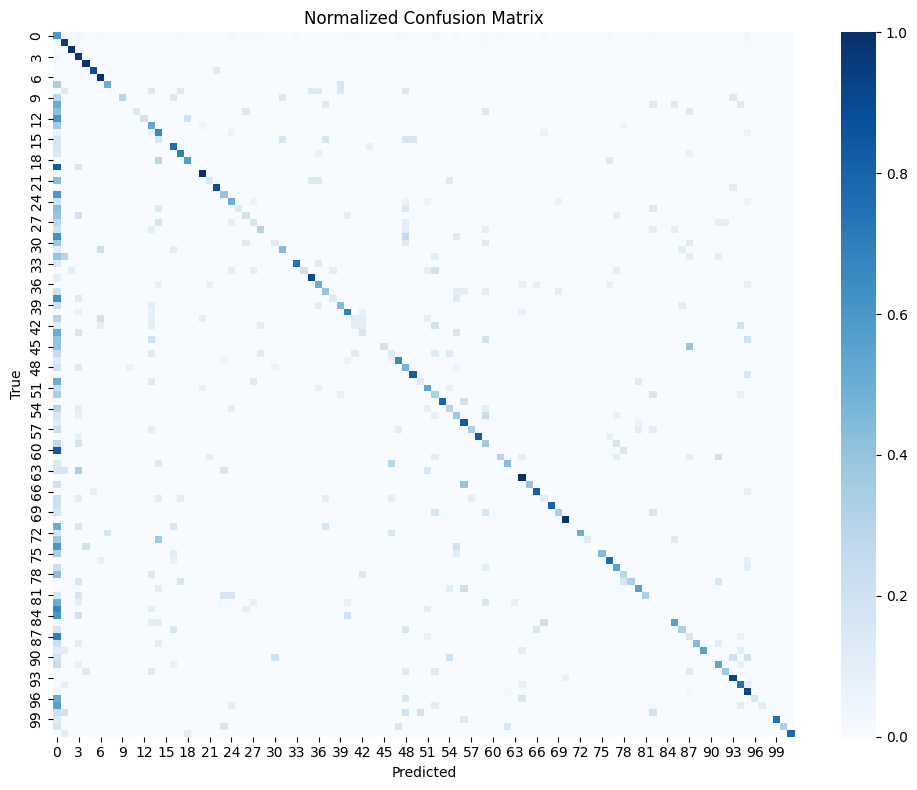

SVM results: {'accuracy': 0.6158892128279884, 'per_class_accuracy': array([0.6       , 0.95384615, 1.        , 0.96666667, 0.99166667,
       0.875     , 0.99166667, 0.5       , 0.        , 0.28571429,
       0.        , 0.14285714, 0.2       , 0.52631579, 0.66666667,
       0.        , 0.76923077, 0.69230769, 0.57142857, 0.        ,
       1.        , 0.14285714, 0.88888889, 0.4       , 0.5       ,
       0.14285714, 0.2       , 0.18181818, 0.3       , 0.        ,
       0.125     , 0.44444444, 0.        , 0.75      , 0.2       ,
       0.9       , 0.5       , 0.4       , 0.125     , 0.44444444,
       0.69230769, 0.1       , 0.1       , 0.        , 0.        ,
       0.2       , 0.125     , 0.66666667, 0.46666667, 0.83333333,
       0.125     , 0.53846154, 0.33333333, 0.8       , 0.3       ,
       0.38461538, 0.82352941, 0.33333333, 0.83333333, 0.36363636,
       0.        , 0.3       , 0.42857143, 0.        , 1.        ,
       0.4       , 0.81818182, 0.11111111, 0.8       , 0.3333

In [ ]:
# train
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score

# Linear SVM + probability calibration
base_svm = LinearSVC(C=1.0, class_weight="balanced", random_state=0)
svm = CalibratedClassifierCV(base_svm, method="sigmoid", cv=3)

svm.fit(X_train, y_train)

# see in val
val_pred = svm.predict(X_val)
print("Val acc (HOG+SVM):", accuracy_score(y_val, val_pred))

# output test
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)

results_svm = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_svm,
    y_prob=y_prob_svm,
    class_names=class_names,
    topk=5
)
print("SVM results:", results_svm)

### DL (CNN) - ResNet

In [ ]:
import torch, os, subprocess, textwrap, sys

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version (torch):", torch.version.cuda)
print("device count:", torch.cuda.device_count())

try:
    out = subprocess.check_output(["bash","-lc","nvidia-smi -L"], stderr=subprocess.STDOUT).decode()
    print("nvidia-smi -L:\n", out)
except Exception as e:
    print("nvidia-smi not available -> likely NO GPU runtime attached.")

torch version: 2.10.0+cu128
cuda available: True
cuda version (torch): 12.8
device count: 1
nvidia-smi -L:
 GPU 0: NVIDIA L4 (UUID: GPU-1447000c-d25d-0c08-9c62-7efdaf863f90)



In [ ]:
# dataset
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class CSVDataset(Dataset):
    def __init__(self, df, label_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "filepath"]
        label = self.df.loc[idx, "label"]
        y = self.label_to_idx[label]
        img = load_image_rgb(fp)
        if self.transform:
            img = self.transform(img)
        return img, y

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tf = T.Compose([
    T.Resize((224, 224)),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = CSVDataset(train_df, label_to_idx, transform=train_tf)
val_ds   = CSVDataset(val_df,   label_to_idx, transform=eval_tf)
test_ds  = CSVDataset(test_df,  label_to_idx, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
# train
import torch.nn as nn
import torchvision.models as models

def build_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), torch.tensor(yb).to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), torch.tensor(yb).to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)
    return total_loss/total, correct/total

In [ ]:
# Epoch 1-10
# train
model_resnet = build_resnet18(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_resnet.parameters(), lr=3e-4, weight_decay=1e-4)

best_val = -1
best_state = None

for epoch in range(1, 11):
    tr_loss, tr_acc = train_one_epoch(model_resnet, train_loader, optimizer, criterion, device)
    va_loss, va_acc = eval_epoch(model_resnet, val_loader, criterion, device)
    print(f"[ResNet] Epoch {epoch}: train acc={tr_acc:.4f} val acc={va_acc:.4f}")

    if va_acc > best_val:
        best_val = va_acc
        best_state = {k:v.cpu().clone() for k,v in model_resnet.state_dict().items()}

# load best
model_resnet.load_state_dict(best_state)

/tmp/ipython-input-1424769987.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xb, yb = xb.to(device), torch.tensor(yb).to(device)
/tmp/ipython-input-1424769987.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xb, yb = xb.to(device), torch.tensor(yb).to(device)


[ResNet] Epoch 1: train acc=0.7141 val acc=0.8797
[ResNet] Epoch 2: train acc=0.9467 val acc=0.9147
[ResNet] Epoch 3: train acc=0.9803 val acc=0.9096
[ResNet] Epoch 4: train acc=0.9888 val acc=0.9213
[ResNet] Epoch 5: train acc=0.9955 val acc=0.9191
[ResNet] Epoch 6: train acc=0.9944 val acc=0.9220
[ResNet] Epoch 7: train acc=0.9933 val acc=0.9009
[ResNet] Epoch 8: train acc=0.9936 val acc=0.9103
[ResNet] Epoch 9: train acc=0.9894 val acc=0.8827
[ResNet] Epoch 10: train acc=0.9842 val acc=0.8863


<All keys matched successfully>

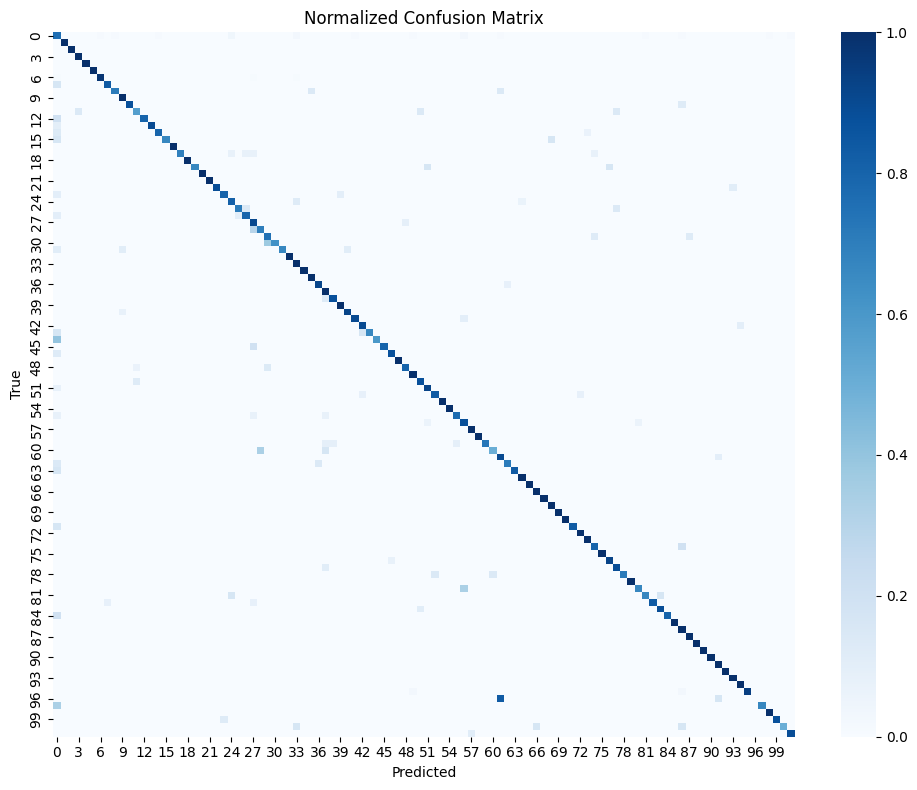

ResNet results: {'accuracy': 0.9074344023323615, 'per_class_accuracy': array([0.75714286, 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.975     , 0.83333333, 0.71428571, 1.        ,
       0.875     , 0.57142857, 0.8       , 0.89473684, 0.8       ,
       0.66666667, 1.        , 0.69230769, 1.        , 0.66666667,
       1.        , 1.        , 0.88888889, 0.8       , 0.8125    ,
       0.71428571, 0.8       , 0.90909091, 0.7       , 0.75      ,
       0.625     , 0.66666667, 1.        , 1.        , 1.        ,
       1.        , 0.91666667, 1.        , 0.875     , 1.        ,
       0.92307692, 0.9       , 0.9       , 0.66666667, 0.6       ,
       0.8       , 0.875     , 1.        , 0.8       , 1.        ,
       0.875     , 0.92307692, 0.83333333, 1.        , 1.        ,
       0.76923077, 0.88235294, 1.        , 1.        , 0.72727273,
       0.5       , 0.9       , 0.71428571, 0.83333333, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1. 

In [ ]:
# evaluate on test dataset
@torch.no_grad()
def predict_probs(model, loader, device, num_classes):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred = probs.argmax(axis=1)

        all_true.append(np.array(yb))
        all_pred.append(pred)
        all_prob.append(probs)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)
    return y_true, y_pred, y_prob

y_true_r, y_pred_r, y_prob_r = predict_probs(model_resnet, test_loader, device, num_classes)

results_resnet = evaluate_classification(
    y_true=y_true_r, y_pred=y_pred_r, y_prob=y_prob_r,
    class_names=class_names, topk=5
)
print("ResNet results:", results_resnet)

### DL (transformer) - ViT

In [ ]:
!pip -q install timm

In [ ]:
# Epoch 1-10
import timm

def build_vit(num_classes):
    model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
    return model

model_vit = build_vit(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_vit.parameters(), lr=3e-4, weight_decay=1e-4)

best_val = -1
best_state = None

for epoch in range(1, 11):
    tr_loss, tr_acc = train_one_epoch(model_vit, train_loader, optimizer, criterion, device)
    va_loss, va_acc = eval_epoch(model_vit, val_loader, criterion, device)
    print(f"[ViT] Epoch {epoch}: train acc={tr_acc:.4f} val acc={va_acc:.4f}")

    if va_acc > best_val:
        best_val = va_acc
        best_state = {k:v.cpu().clone() for k,v in model_vit.state_dict().items()}

model_vit.load_state_dict(best_state)

/tmp/ipython-input-1424769987.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xb, yb = xb.to(device), torch.tensor(yb).to(device)
/tmp/ipython-input-1424769987.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xb, yb = xb.to(device), torch.tensor(yb).to(device)


[ViT] Epoch 1: train acc=0.6894 val acc=0.8404
[ViT] Epoch 2: train acc=0.8716 val acc=0.8688
[ViT] Epoch 3: train acc=0.9184 val acc=0.8622
[ViT] Epoch 4: train acc=0.9233 val acc=0.8397
[ViT] Epoch 5: train acc=0.9253 val acc=0.8448
[ViT] Epoch 6: train acc=0.9416 val acc=0.8418
[ViT] Epoch 7: train acc=0.9467 val acc=0.8404
[ViT] Epoch 8: train acc=0.9592 val acc=0.8338
[ViT] Epoch 9: train acc=0.9450 val acc=0.8338
[ViT] Epoch 10: train acc=0.9527 val acc=0.8433


<All keys matched successfully>

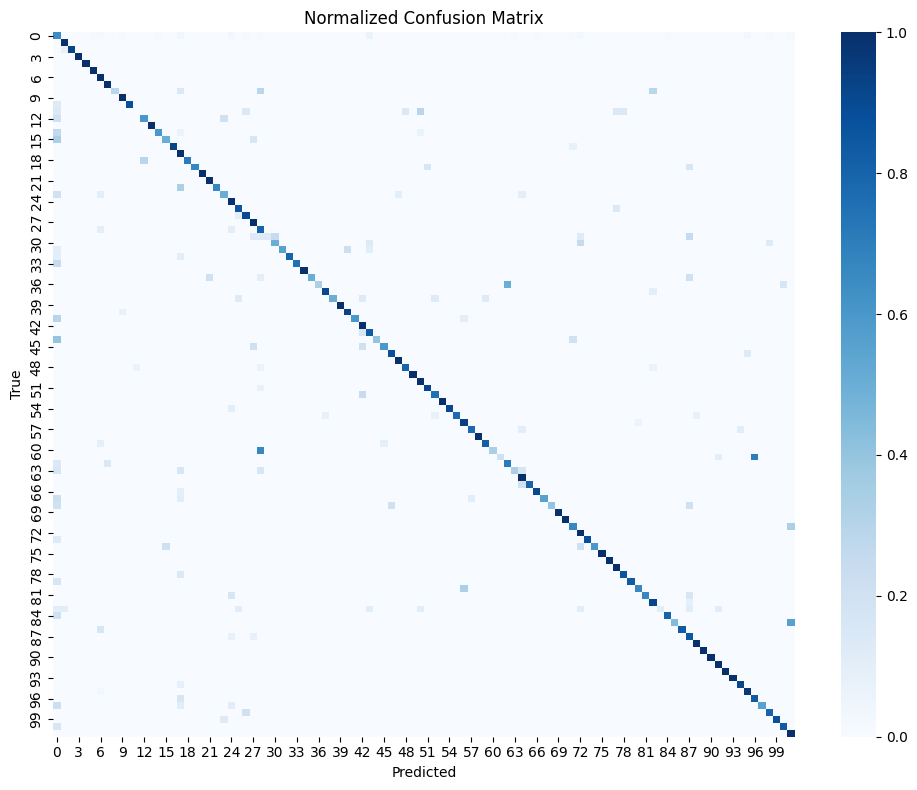

ViT results: {'accuracy': 0.8520408163265306, 'per_class_accuracy': array([0.64285714, 1.        , 0.92424242, 1.        , 1.        ,
       1.        , 1.        , 1.        , 0.28571429, 1.        ,
       0.875     , 0.        , 0.6       , 1.        , 0.6       ,
       0.5       , 0.92307692, 1.        , 0.71428571, 0.66666667,
       1.        , 1.        , 0.66666667, 0.5       , 1.        ,
       0.85714286, 0.9       , 1.        , 0.8       , 0.125     ,
       0.5       , 0.55555556, 0.8       , 0.75      , 1.        ,
       0.5       , 0.33333333, 0.9       , 0.5       , 1.        ,
       0.92307692, 0.6       , 1.        , 0.83333333, 0.4       ,
       0.6       , 0.875     , 1.        , 0.8       , 1.        ,
       1.        , 0.92307692, 0.75      , 1.        , 0.9       ,
       0.76923077, 0.94117647, 0.77777778, 1.        , 0.81818182,
       0.33333333, 0.2       , 0.71428571, 0.33333333, 1.        ,
       0.8       , 0.90909091, 0.55555556, 0.4       , 1.    

In [ ]:
# Evaluate on Test
y_true_v, y_pred_v, y_prob_v = predict_probs(model_vit, test_loader, device, num_classes)

results_vit = evaluate_classification(
    y_true=y_true_v, y_pred=y_pred_v, y_prob=y_prob_v,
    class_names=class_names, topk=5
)
print("ViT results:", results_vit)

In [ ]:
# summarize
summary = pd.DataFrame([
    {"model":"HOG+SVM", **{k:v for k,v in results_svm.items() if k!="per_class_accuracy"}},
    {"model":"ResNet", **{k:v for k,v in results_resnet.items() if k!="per_class_accuracy"}},
    {"model":"ViT", **{k:v for k,v in results_vit.items() if k!="per_class_accuracy"}},
])
summary

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy
0,HOG+SVM,0.615889,0.566746,0.423295,0.447217,0.644811,0.615889,0.596672,0.768950
1,ResNet,0.907434,0.895307,0.872720,0.874911,0.916412,0.907434,0.906484,0.984694
2,ViT,0.852041,0.860012,0.789013,0.790285,0.882177,0.852041,0.845317,0.965743


## Ablation Studies
#### To deepen learning, run at least two small ablation experiments:


*   Image size: compare 64 × 64 vs. 128 × 128
*   Data augmentation: train with vs without augmentation


*   Feature extractor choice: HOG vs CNN features
*   Optimizer: SGD vs Adam for CNN





**Best Model: ResNet**

In [ ]:
# Setup
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def load_image_rgb(path):
    return Image.open(path).convert("RGB")

class CSVDataset(Dataset):
    def __init__(self, df, label_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fp = self.df.loc[idx, "filepath"]
        label = self.df.loc[idx, "label"]
        y = self.label_to_idx[label]
        img = load_image_rgb(fp)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(y, dtype=torch.long)

def build_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def predict_probs(model, loader, device):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred = probs.argmax(axis=1)
        all_true.append(yb.numpy())
        all_pred.append(pred)
        all_prob.append(probs)
    return np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_prob)

device: cuda


In [ ]:
# ablation
# change image size & augmentation
def make_transforms(image_size=128, augment=True):
    normalize = T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    if augment:
        train_tf = T.Compose([
            T.Resize((image_size, image_size)),
            T.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            normalize,
        ])
    else:
        train_tf = T.Compose([
            T.Resize((image_size, image_size)),
            T.CenterCrop(image_size),
            T.ToTensor(),
            normalize,
        ])
    eval_tf = T.Compose([
        T.Resize((image_size, image_size)),
        T.CenterCrop(image_size),
        T.ToTensor(),
        normalize,
    ])
    return train_tf, eval_tf

In [ ]:
# train ResNet
def run_resnet_experiment(
    image_size=128,
    augment=True,
    epochs=5,
    batch_size=64,
    lr=3e-4,
    weight_decay=1e-4,
    seed=0
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_tf, eval_tf = make_transforms(image_size=image_size, augment=augment)

    train_ds = CSVDataset(train_df, label_to_idx, transform=train_tf)
    val_ds   = CSVDataset(val_df,   label_to_idx, transform=eval_tf)
    test_ds  = CSVDataset(test_df,  label_to_idx, transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    num_classes = len(label_to_idx)
    model = build_resnet18(num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = -1
    best_state = None

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = eval_epoch(model, val_loader, criterion, device)
        print(f"[ResNet][size={image_size}][aug={augment}] ep{ep}: train_acc={tr_acc:.4f} val_acc={va_acc:.4f}")

        if va_acc > best_val:
            best_val = va_acc
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state)

    y_true, y_pred, y_prob = predict_probs(model, test_loader, device)

    results = evaluate_classification(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob,
        class_names=class_names,
        topk=5
    )

    flat = {k:v for k,v in results.items() if k!="per_class_accuracy"}
    flat.update({
        "image_size": image_size,
        "augmentation": augment,
        "best_val_acc": best_val
    })
    return flat

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


[ResNet][size=64][aug=False] ep1: train_acc=0.5859 val_acc=0.7682
[ResNet][size=64][aug=False] ep2: train_acc=0.8884 val_acc=0.7959
[ResNet][size=64][aug=False] ep3: train_acc=0.9777 val_acc=0.8287
[ResNet][size=64][aug=False] ep4: train_acc=0.9959 val_acc=0.8389
[ResNet][size=64][aug=False] ep5: train_acc=0.9981 val_acc=0.8484


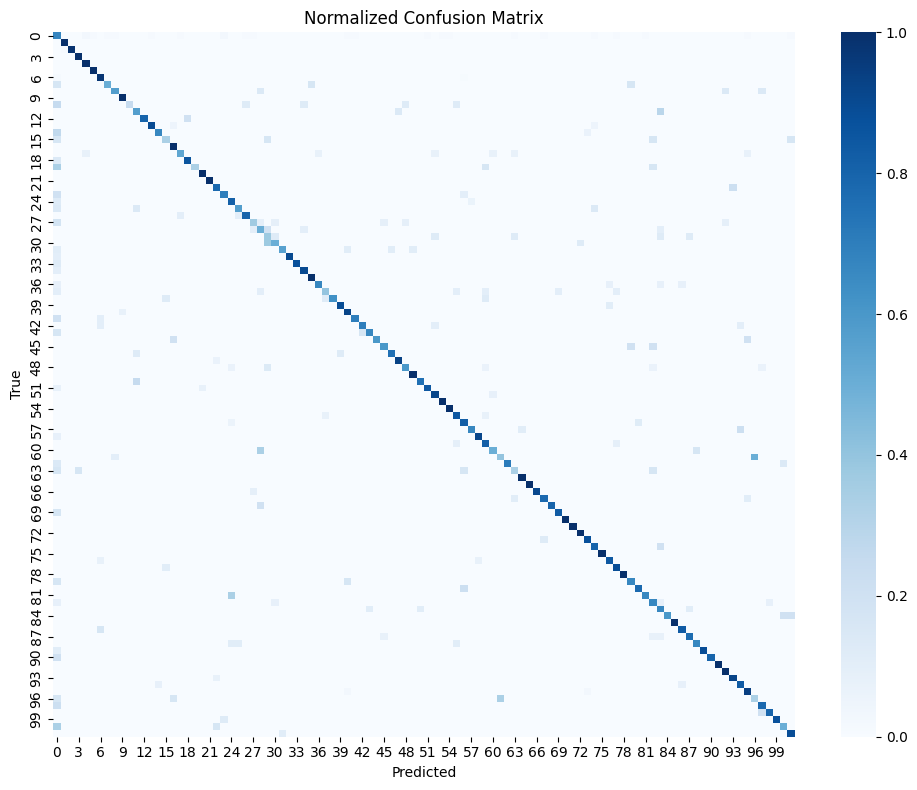

[ResNet][size=64][aug=True] ep1: train_acc=0.5584 val_acc=0.7413
[ResNet][size=64][aug=True] ep2: train_acc=0.8148 val_acc=0.7828
[ResNet][size=64][aug=True] ep3: train_acc=0.8919 val_acc=0.8083
[ResNet][size=64][aug=True] ep4: train_acc=0.9328 val_acc=0.8039
[ResNet][size=64][aug=True] ep5: train_acc=0.9458 val_acc=0.7988


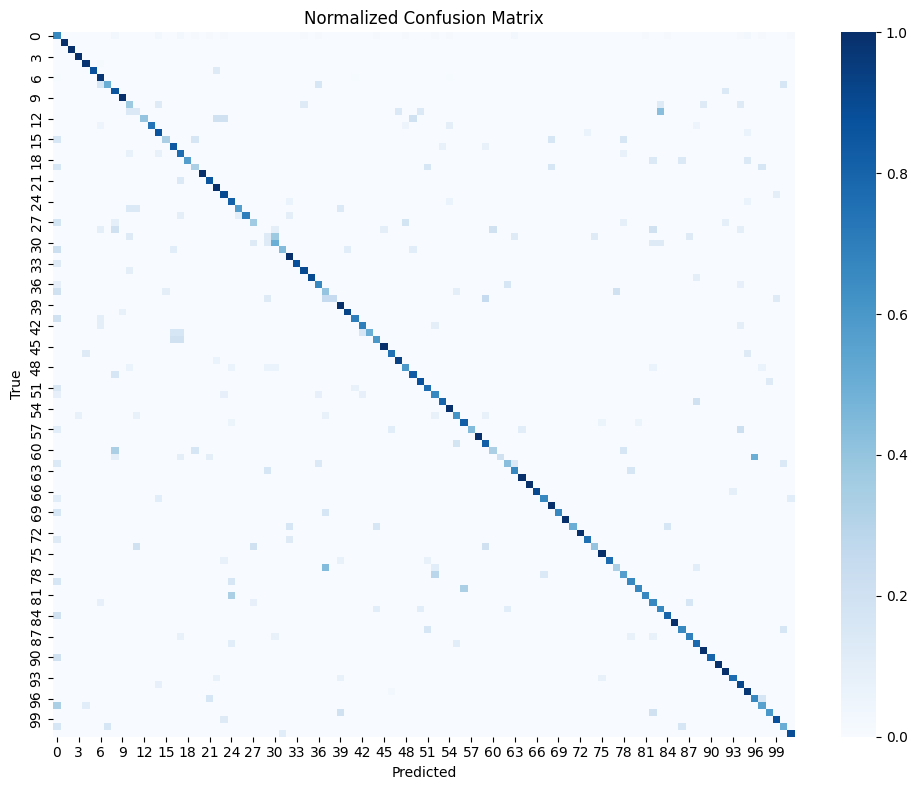

[ResNet][size=128][aug=False] ep1: train_acc=0.7258 val_acc=0.8805
[ResNet][size=128][aug=False] ep2: train_acc=0.9716 val_acc=0.8943
[ResNet][size=128][aug=False] ep3: train_acc=0.9956 val_acc=0.9162
[ResNet][size=128][aug=False] ep4: train_acc=0.9989 val_acc=0.9337
[ResNet][size=128][aug=False] ep5: train_acc=0.9989 val_acc=0.9264


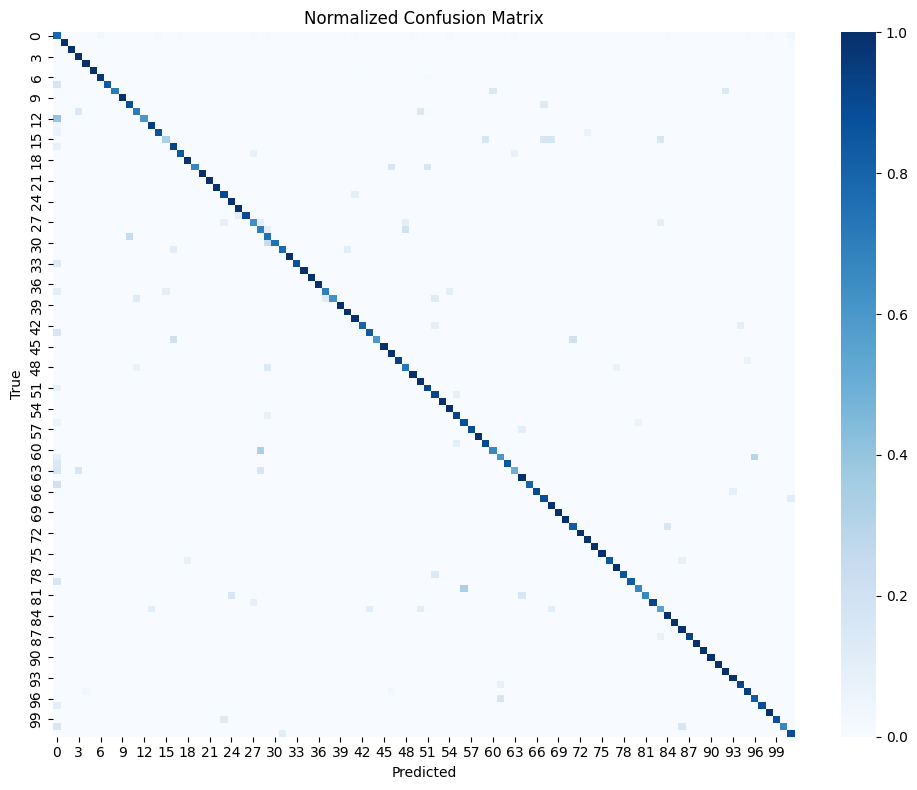

[ResNet][size=128][aug=True] ep1: train_acc=0.6994 val_acc=0.8564
[ResNet][size=128][aug=True] ep2: train_acc=0.9303 val_acc=0.8557
[ResNet][size=128][aug=True] ep3: train_acc=0.9666 val_acc=0.8863
[ResNet][size=128][aug=True] ep4: train_acc=0.9819 val_acc=0.8885
[ResNet][size=128][aug=True] ep5: train_acc=0.9891 val_acc=0.8863


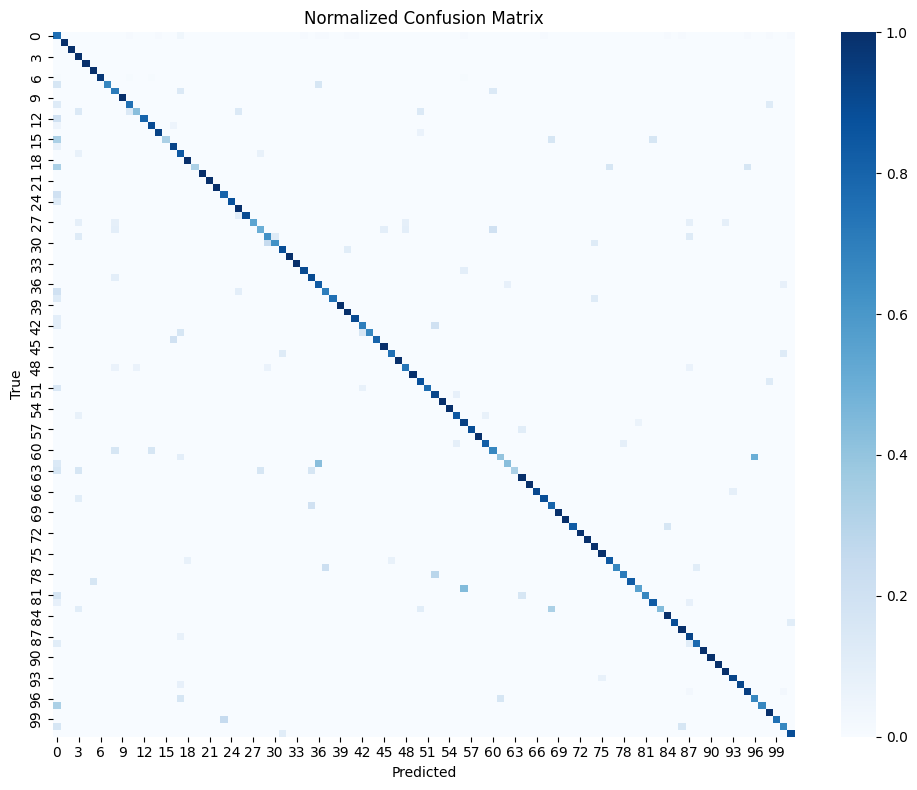

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy,image_size,augmentation,best_val_acc
0,0.836735,0.812428,0.772281,0.781405,0.847199,0.836735,0.834963,0.951166,64,False,0.848397
1,0.806122,0.754680,0.724017,0.720872,0.813702,0.806122,0.798522,0.927114,64,True,0.808309
2,0.915452,0.904683,0.885923,0.888448,0.921557,0.915452,0.914842,0.983965,128,False,0.933673
3,0.883382,0.877886,0.839494,0.843394,0.898975,0.883382,0.882071,0.972303,128,True,0.888484


In [ ]:
# first start with epochs=5
ablation_rows = []
for image_size in [64, 128]:
    for augment in [False, True]:
        out = run_resnet_experiment(
            image_size=image_size,
            augment=augment,
            epochs=5,
            batch_size=64,
            lr=3e-4,
            seed=42
        )
        ablation_rows.append(out)

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.sort_values(["image_size", "augmentation"])

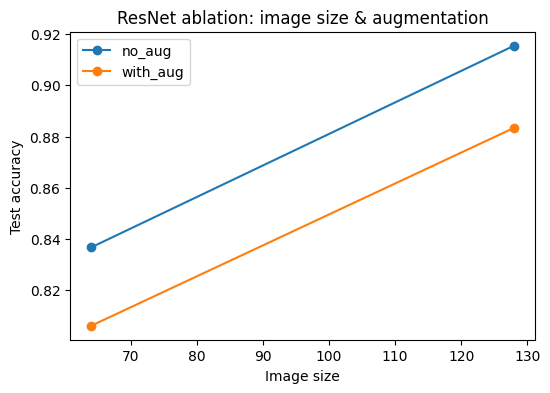

In [ ]:
# plot
import matplotlib.pyplot as plt

plot_df = ablation_df.copy()
plot_df["aug"] = plot_df["augmentation"].map({True:"with_aug", False:"no_aug"})

plt.figure(figsize=(6,4))
for aug in ["no_aug","with_aug"]:
    sub = plot_df[plot_df["aug"]==aug].sort_values("image_size")
    plt.plot(sub["image_size"], sub["accuracy"], marker="o", label=aug)
plt.xlabel("Image size")
plt.ylabel("Test accuracy")
plt.title("ResNet ablation: image size & augmentation")
plt.legend()
plt.show()